In [1]:
import os
from printer import print_batch
from cosmos_predict2.data.action_conditioned.action_conditioned_dataset import ActionConditionedDataset

In [4]:
base_path = "../datasets/bridge/"
train_annotation_path = os.path.join(base_path, "annotation/train")
val_annotation_path = os.path.join(base_path, "annotation/val")
test_annotation_path = os.path.join(base_path, "annotation/test")

In [5]:
bridge_train_dataset = ActionConditionedDataset(
    train_annotation_path=train_annotation_path,
    val_annotation_path=val_annotation_path,
    test_annotation_path=test_annotation_path,
    video_path=base_path,
    sequence_interval=1,
    num_frames=13,
    cam_ids=[0],
    accumulate_action=False,
    video_size=[480, 640],
    val_start_frame_interval=1,
    mode="train",
)

25460 trajectories in total


100%|█████████████████████████████████████████████████████████████████████████████████| 25460/25460 [00:16<00:00, 1533.73it/s]


25460 trajectories in total
558787 samples in total


In [18]:
""" Bridge Dataset Debug """
dataset_sample = bridge_train_dataset[900]
print_batch("sample", dataset_sample)
print("video:", dataset_sample['video'].min())
print("annotation_file:", dataset_sample['annotation_file'])
print("image_size:", dataset_sample['image_size'])

sample: Dict,keys=dict_keys(['action', 'video', 'annotation_file', '__key__', 't5_text_embeddings', 't5_text_mask', 'fps', 'image_size', 'num_frames', 'padding_mask'])
action,<class 'torch.Tensor'>,shape=torch.Size([12, 7])
video,<class 'torch.Tensor'>,shape=torch.Size([3, 13, 480, 640])
annotation_file:<class 'str'>,len=46
__key__:<class 'str'>,len=5
t5_text_embeddings,<class 'torch.Tensor'>,shape=torch.Size([512, 1024])
t5_text_mask,<class 'torch.Tensor'>,shape=torch.Size([512])
fps:<class 'int'>,4
image_size,<class 'torch.Tensor'>,shape=torch.Size([4])
num_frames:<class 'int'>,13
padding_mask,<class 'torch.Tensor'>,shape=torch.Size([1, 256, 256])
video: tensor(0, dtype=torch.uint8)
annotation_file: ../datasets/bridge/annotation/train/10035.json
image_size: tensor([256., 256., 256., 256.])


'0'

In [15]:
""" PushT Dataset Debug """
from cosmos_predict2.data.action_conditioned.pusht_dataset import PushTImageDataset

pusht_dataset = PushTImageDataset(
    # zarr_path="../datasets/pusht/pusht_cchi_v7_replay.zarr", 
    zarr_path="../datasets/pusht/pusht_256_val.zarr", 
    horizon=50,
    pad_before=0,
    pad_after=8,
)
print(len(pusht_dataset))

[PushTImageDataset] Loaded from: ../datasets/pusht/pusht_256_val.zarr, len=784.
784


In [11]:
pusht_sample = pusht_dataset[10]
print_batch("pusht_sample", pusht_sample)
# print("['obs']['image']:", pusht_sample['obs']['image'].min())
# print("['obs']['agent_pos']:", pusht_sample['obs']['agent_pos'])
# print("['action']:", pusht_sample['action'])

pusht_sample: Dict,keys=dict_keys(['action', 'video', 'annotation_file', '__key__', 't5_text_embeddings', 't5_text_mask', 'fps', 'image_size', 'num_frames', 'padding_mask'])
action,<class 'torch.Tensor'>,shape=torch.Size([16, 2])
video,<class 'torch.Tensor'>,shape=torch.Size([3, 16, 256, 256])
annotation_file:<class 'str'>,len=4
__key__:<class 'str'>,len=4
t5_text_embeddings,<class 'torch.Tensor'>,shape=torch.Size([512, 1024])
t5_text_mask,<class 'torch.Tensor'>,shape=torch.Size([512])
fps:<class 'int'>,5
image_size,<class 'torch.Tensor'>,shape=torch.Size([4])
num_frames:<class 'int'>,16
padding_mask,<class 'torch.Tensor'>,shape=torch.Size([1, 256, 256])


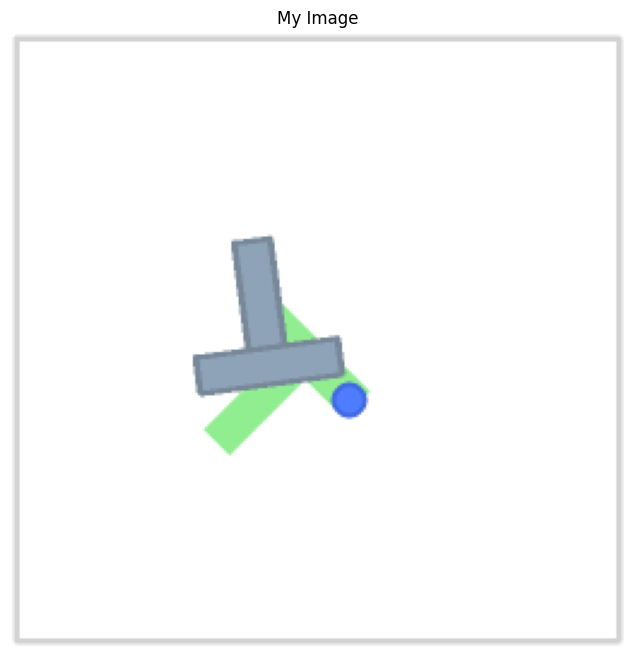

In [12]:
import matplotlib.pyplot as plt
vis_img = pusht_sample['video'][:,0]
vis_img = vis_img.permute(1,2,0)
plt.figure(figsize=(10, 8))
plt.imshow(vis_img)
plt.axis('off')  # 隐藏坐标轴
plt.title('My Image')
plt.show()